# Week 3 - Probability Distributions 1 and 2

Learning contents:

1. Frequenist's approach
    - Bernoulli distribution function
    - Maximum Likelihood
    - Display distribution
2. Bayesian approach
    - Binomial distribution
    - Display Binomial distribution for different m
    - Maximum posterior
3. Multinomial variables
    - Generate data
    - Frequenist's approach
        - Multinomial Bernoulli distribution function
        - Maximum likelihood
4. Gaussian distribution
    - Distribution function
    - Generate data
    - Display data
    - Frequenist's approach
        - Maximum likelihood
        - Display distribution
    - Bayesian approach
        - Generate data
        - Variance is known, mean is unknown
        - Display mean estimation for different N

## Dependencies

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from math import exp, sqrt
from collections import Counter
from scipy.special import comb
from scipy.stats import beta
from scipy.stats import multivariate_normal, norm

import seaborn as sns; sns.set(); sns.set_palette('bright')

## Generate Data

The code listed below defines 2 functions: 'weighted_coin' gives an output of a random experiment involving a single toss of a loaded or weighted coin. The probability of getting 'heads' is 0.7, whereas the probability of getting 'tails' is 0.3. In the case of heads, the function outputs 1, else it outputs 0.

Generate_data() then generates samples from the 'weighted_coin' random experiment. We generate 10,000 samples using this function.

In [2]:
random.seed(2605)

def weighted_coin(heads=0.7, tails=0.3):
    total = heads + tails
    value = random.random() * total
    result = 0 if value <= tails else 1
    return result


def generate_data(size):
    return list(map(
        lambda i: weighted_coin(),
        range(size)
    ))


train_size = 10000
train_data = generate_data(train_size)

<BarContainer object of 2 artists>

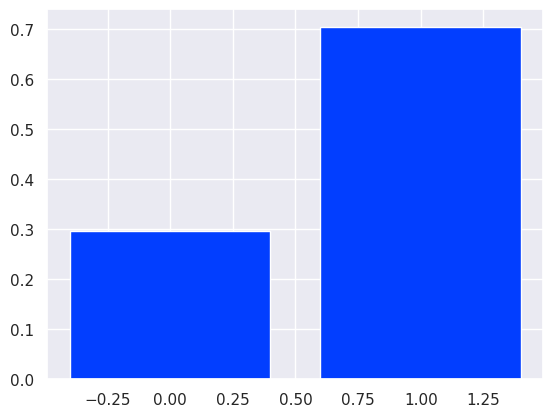

In [3]:
counter = Counter(train_data)
plt.bar(counter.keys(), list(map(lambda a: a / train_size, counter.values())))

## 1) Frequenist's approach

### 1.1) Bernoulli distribution function

write the function 'bern' that outputs the probability density function value of a bernoulli ramdom variable 'x' and paramater 'mu' (see slide 7 in lecture 5).

In [4]:
def bern(x, mu):
    return mu**x * (1-mu)**(1-x)

### 1.2) Maximum Likelihood

write the function mu_maximum_likelihood_bern that takes data points train_data and should return the Maximum Likelihood estimate of the parameter 'mu' of the Bernoulli distribution (slide 9 of lecture 5). Is your estimate of 'mu' close to the theoretical value? Also, convince yourself that the 'train_data' that you generated above does belong to Bernoulli distribution!

In [5]:
def mu_maximum_likelihood_bern(train_data):
    return sum(train_data) / len(train_data)

mu_ml = mu_maximum_likelihood_bern(train_data)

### 1.3) Display distribution

The function below plots the probability density (or mass) function of a Bernoulli random variable. Why is this function discrete?

In [6]:
def display_bernoulli(mu, color='b'):

    #xs = np.linspace(0., 1., 100)
    ys = list(map(
        lambda x: bern(x, mu),
        [0,1]
    ))

    plt.bar([0,1],ys)

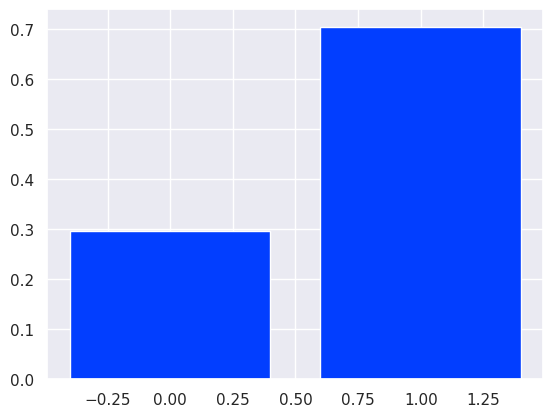

In [7]:
display_bernoulli(mu_ml)

The probability density function is discrete since it is of a Bernoulli distribution, which is a discrete probability distribution.

## 2) Bayesian approach

### 2.1) Binomial distribution

write a function that gives the value of probability density function for Binomial random variable with input parameters 'm', 'N' and 'mu'. Note that 'm' denotes the number of successes in 'N' bernoulli trials or expriments and represents a binomial random variable. 

In [8]:
def binomial(m, N, mu):
    return comb(N, m) * mu**m * (1 - mu)**(N - m)

### 2.2) Display Binomial distribution for different m

In [9]:
def display_binomial(N, mu):
    xs = list(range(N))
    ys = list(map(
        lambda m: binomial(m, N, mu),
        xs
    ))
    
    plt.bar(xs, ys)
    plt.xlabel('m')

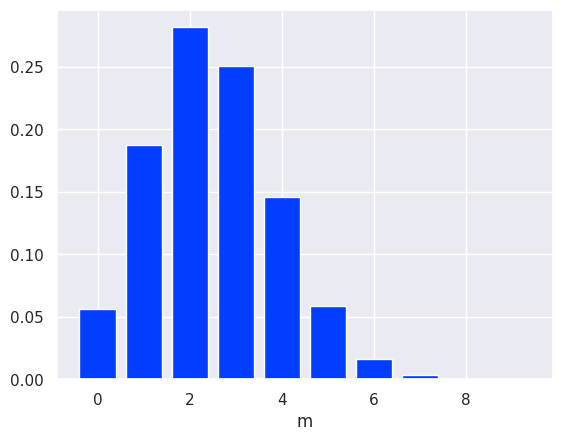

In [10]:
display_binomial(10, 0.25)

### 2.3) Maximum posterior

write a function 'mu_maximum_posterior_bern' which takes parameters 'm', 'N', 'a', 'b' and should return the Maximum Posterior estimate of the parameter 'mu' of the Bernoulli distribution (see the slide 18 in lecture 5). Compare this estimate with that obtained earlier in section 1.2 using maximum likelihood estimator. How the two estimators compare for large values of 'N'?

In [11]:
def mu_maximum_posterior_bern(m, N, a, b):
    l = N - m
    return (m + a) / (m + a + l + b)

In [12]:
print(mu_maximum_posterior_bern(sum(train_data), train_size, 0.1, 0.1))

0.7044959100817983


In [13]:
mu_ml

0.7045

The two estimates are equal at a precision of 0.001. They differ a bit, but for larger values of N, they would become even closer. Since they both estimate the same parameter, they should be the same value at a large enough N.

## 3) Multinomial variables

### 3.1) Generate data

generate samples of the multinomial random variable using 1-of-K scheme (see slide 21 of week 5). While the code is provided here, it is highly recommended to understand how the function has been implemented.

In [14]:
np.random.seed(26)

def generate_multinomial_data(size, probabilities):
    numbers = np.random.choice(len(probabilities), size, 1, probabilities)
    
    result = np.zeros((numbers.size, len(probabilities)))
    result[np.arange(numbers.size), numbers] = 1
    return result
    
probabilities=[0.5, 0.1, 0.2, 0.1, 0.1]
multinomial_data = generate_multinomial_data(100, probabilities)
multinomial_data

array([[1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0.],
       [1., 0.

### 3.2) Frequenist's approach

#### 3.2.1) Multinomial distribution function

Write a function bern_multi(xs, mus) that computes the probability of a single multinomial outcome.

xs: a one-hot encoded vector of length 𝐾
K, representing the observed outcome (which category occurred).
Example: [0,1,0,0] means category 2 was observed.

mus: probability vector of length 𝐾
K, where each entry is the probability of a category and all entries sum to 1.
Example: [0.2, 0.5, 0.3].

(see slide 21 of week 5)

In [15]:
def bern_multi(xs, mus):
    product = 0
    for x, mu in zip(xs, mus):
        product *= mu**x
    return product

#### 3.2.2) Maximum likelihood

`mu_maximum_likelihood_multinomial_bern' takes multinomial data points, 'multinomial_data', and return Maximum Likelihood estimate of the parameters 'mus' of the Multinomial distribution (See slide 23 in Lecture 5). Print the estimated parameter values and compare those with the actual values. If they are different, how could you bring them closer?

In [16]:
def mu_maximum_likelihood_multinomial_bern(multinomial_data):
    return sum(multinomial_data) / len(multinomial_data)

multi_mu_ml = mu_maximum_likelihood_multinomial_bern(multinomial_data)
multi_mu_ml

array([0.46, 0.1 , 0.23, 0.06, 0.15])

In [17]:
probabilities

[0.5, 0.1, 0.2, 0.1, 0.1]

They are pretty close to one another, but differ a bit. To bring them closer more data points/samples could be used.

## 4) Gaussian distribution

### 4.1) Multivariate Gaussian Distribution Function

Write a function multi_gaussian(x, mean, covariance) that returns the probability density of the Gaussian distribution.

x: data point (scalar or vector)

mean: mean (scalar for 1D, vector for multivariate)

covariance: variance (1D) or covariance matrix (multivariate)

You may either:

Use the built-in method scipy.stats.multivariate_normal.pdf, or

Implement the formula in slide 6 (week 6) from scratch.

Test your function with both 1D and 2D cases to build intuition.

In [18]:
def multi_gaussian(x, mean, covariance):
    D = len(x) if type(x) == np.ndarray else 1
    return 1 / ((2*np.pi)**(D/2) * np.linalg.det(covariance)**(1/2)) * exp(- 1/2 * (x - mean).T @ np.linalg.inv(covariance)  @ (x - mean))

I make the 2D and 1D cases using the function from the next exercise (4.2). I then find all the probabilities and plot them to visualize the probability density plot.

/tmp/ipykernel_6233/884609798.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


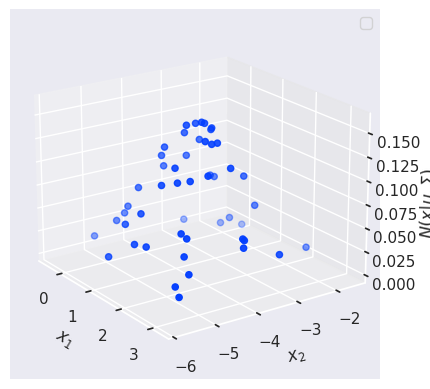

In [19]:
def generate_multi_gaussian_data(size, mean, covariance):
    return np.array(multivariate_normal(mean=mean, cov=covariance).rvs(size=size, random_state=26))

target_mean = [1.7, -4]
target_cov = [[1, 0.1], [0.1, 1]]
multi_gaussian_data = generate_multi_gaussian_data(50, target_mean, target_cov)

z_data = []
for data in multi_gaussian_data:
    z_data.append(multi_gaussian(data, target_mean, target_cov))

ax = plt.figure().add_subplot(projection='3d')
ax.scatter(multi_gaussian_data[:,0], multi_gaussian_data[:,1], z_data)
ax.set_xlabel(f'$x_{1}$')
ax.set_ylabel(f'$x_{2}$')
ax.set_zlabel(f'$N(x|\mu,\Sigma)$')
ax.legend()
ax.view_init(elev=20., azim=-35, roll=0)

/tmp/ipykernel_6233/2820684978.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


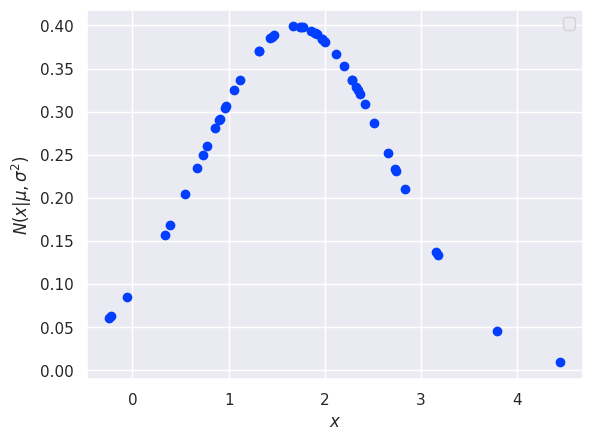

In [20]:
target_mean = [1.7]
target_cov = [[1]]
multi_gaussian_data = generate_multi_gaussian_data(50, target_mean, target_cov)

y_data = []
for data in multi_gaussian_data:
    y_data.append(multi_gaussian(data, target_mean, target_cov))

ax = plt.figure().add_subplot()
ax.scatter(multi_gaussian_data, y_data)
ax.set_xlabel(f'$x$')
ax.set_ylabel(f'$N(x|\mu,\sigma^2)$')
ax.legend()

### 4.2) Generate data

The function below generates 'size' number of random samples from multivariate Gaussian distribution with a specified mean and covariance.

In [21]:
def generate_multi_gaussian_data(size, mean, covariance):
    return np.array(multivariate_normal(mean=mean, cov=covariance).rvs(size=size, random_state=26))

target_mean = [1.7, -4]
target_cov = [[1, 0.1], [0.1, 1]]
multi_gaussian_data = generate_multi_gaussian_data(50, target_mean, target_cov)

### 4.3) Display data

See the output of the code below and understand the Gaussian contour plots. What do the smaller contours (in the center) represent in that figure? Where do the majority of the data points (blue dots) lie and why? 

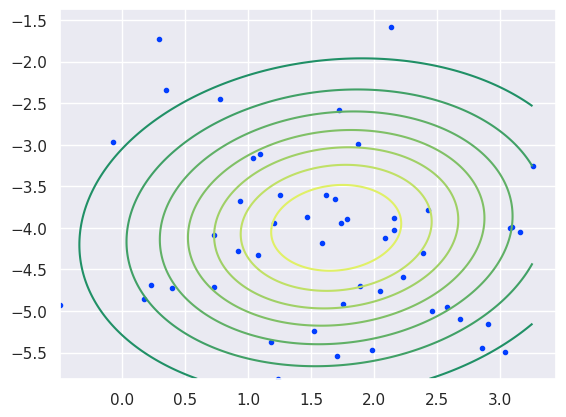

In [22]:
plt.plot(multi_gaussian_data[:, 0], multi_gaussian_data[:, 1], '.')

def display_gaussian_contour(data, mean, covariance, cmap='summer'):

    lx = min(data[:, 0])
    rx = max(data[:, 0])
    by = min(data[:, 1])
    uy = max(data[:, 1])

    x, y = np.mgrid[lx:rx:.01, by:uy:.01]
    pos = np.dstack((x, y))
    plt.contour(x, y, multivariate_normal(mean, covariance).pdf(pos), cmap=cmap)

display_gaussian_contour(multi_gaussian_data, target_mean, target_cov)

The innermost smaller contours represents the value most data will lie within in the distribution. Since all the contours encircle the mean. The covariance is then represented by how far out the other contours go.

### 4.4) Parameter Estimation using Frequenist's approach

#### 4.4.1) Maximum likelihood

write the `multi_gaussian_mu_maximum_likelihood` function that takes Gaussian distributed data points `multi_gaussian_data` and should return Maximum Likelihood estimate of the mean of Multivariate Gaussian distribution (Slide 10 of lecture 6).

In [23]:
def multi_gaussian_mu_maximum_likelihood(multi_gaussian_data):
    return sum(multi_gaussian_data) / len(multi_gaussian_data)

g_mu_ml = multi_gaussian_mu_maximum_likelihood(multi_gaussian_data)
g_mu_ml

array([ 1.64301733, -4.13747801])

Write the function `multi_gaussian_covariance_maximum_likelihood` that takes Gaussian data points `multi_gaussian_data` and Maximum Likelihood estimate for `mu` (`g_mu_ml`) and should return Maximum Likelihood estimate of the covariance matrix of that distribution (slide 12 of lecture 6).

In [24]:
def multi_gaussian_covariance_maximum_likelihood(multi_gaussian_data, g_mu_ml):
    sumpart = np.zeros((2,2))
    for x in multi_gaussian_data:
        sumpart += (x - g_mu_ml)[:, np.newaxis] @ (x - g_mu_ml)[:, np.newaxis].T
    return 1 / (len(multi_gaussian_data) - 1) * sumpart

g_cov_ml = multi_gaussian_covariance_maximum_likelihood(multi_gaussian_data, g_mu_ml)
g_cov_ml

array([[ 0.84757357, -0.18427121],
       [-0.18427121,  0.97482937]])

#### 4.4.2) Display distribution

Displaying and comparing between the estimated distribution and the true distribution. Should and Do they appear close together? 

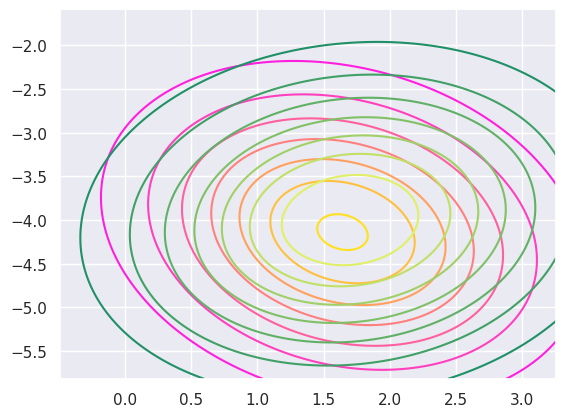

In [25]:
display_gaussian_contour(multi_gaussian_data, g_mu_ml, g_cov_ml, cmap='spring')
display_gaussian_contour(multi_gaussian_data, target_mean, target_cov, cmap='summer')

They aren't exact matches, but since the mean and covariances are estimations of "only" 50 samples it makes sense. Since they still are estimations of the true value, the estimated distribution should still have similarities, which can also be seen since the means/centers are kind of close, and the axes of the contours makes it look like the estimated distribution is encapsuled by the true distribution.

### 4.5) Parameter Estimation using Bayesian approach

Here, we will implement Gaussian parameter estimation methods using the Bayesian approach. The generated Gaussian data points will be univariate in this case.  

#### 4.5.1) Generate data

Generate 50 samples of univariate Gaussian data with mean=0.8 and variance=0.1

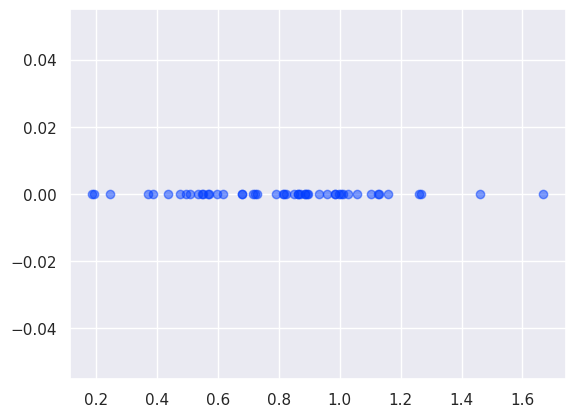

In [26]:
def generate_gaussian_data(size, mean, variance):
    return np.array(norm(mean, sqrt(variance)).rvs(size=size, random_state=26))

g_mean = 0.8
g_variance = 0.1
gaussian_data = generate_gaussian_data(50, g_mean, g_variance)

plt.scatter(gaussian_data, [0] * len(gaussian_data), alpha=0.5)

#### 4.5.2) Estimating mean distribution when the variance is known

write the function `multi_gaussian_mu_maximum_posterior` that takes data points `gaussian_data`, prior mean `mu0` and prior variance `variance0`, actual variance of the distribution, `variance`, and should return the parameters (mean and variance) of the Posterior Mean distribution (see the last 2 equations in slide 15 of lecture 6). See section 2.3.6 for details.

In [27]:
def multi_gaussian_mu_maximum_posterior(gaussian_data, mu0, variance0, variance):
    N = len(gaussian_data)
    meanN = variance / (N * variance0 + variance) * mu0 + (N * variance0) / (N * variance0 + variance) * multi_gaussian_mu_maximum_likelihood(gaussian_data)
    varianceN = 1 / (1 / variance0 + N / variance)
    return meanN, varianceN

g_mu_map, g_mu_var_map = multi_gaussian_mu_maximum_posterior(gaussian_data, 0, g_variance, g_variance)
g_mu_map, g_mu_var_map

(0.7873049121325897, 0.00196078431372549)

#### 4.5.3) Display mean estimation for different values of N

Looking at the plots below, why does the mean distribution gets more and more concentrated around true value as the number of samples increase? What benefits this Bayesian approach offers over maximum likelihood approach?

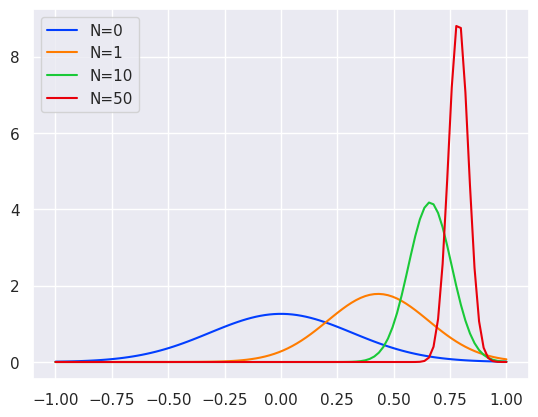

In [28]:
def display_mu_map(gaussian_data, mu0, variance0, variance):
    N = len(gaussian_data)
    x = np.linspace(-1, 1, 100)
    if N == 0:
        y = norm(mu0, np.sqrt(variance0)).pdf(x)
    else:
        g_mu_map, g_mu_var_map = multi_gaussian_mu_maximum_posterior(gaussian_data, 0, g_variance, g_variance)
        y = norm(g_mu_map, sqrt(g_mu_var_map)).pdf(x)
    plt.plot(x, y, label='N=' + str(len(gaussian_data)))
    plt.legend()

display_mu_map(gaussian_data[:0], 0, g_variance, g_variance)
display_mu_map(gaussian_data[:1], 0, g_variance, g_variance)
display_mu_map(gaussian_data[:10], 0, g_variance, g_variance)
display_mu_map(gaussian_data, 0, g_variance, g_variance)

As the number of samples increases, more data will be averaged out which will decrease uncertainty and make the mean distribution more concentrated on the true mean.

The benefit of the Bayesian approach is that prior knowledge of the mean/variance can be incorporated and that it shows uncertainty through a mean distribution instead of only estimating a value. Furthermore, it can be seen that with little information ($N=1$ or even $N=0$), the estimated mean distribution still contains the true value of the mean, though with high uncertainty, meaning that it is a great approach, when you have little information/few samples.